# Indian Unemployment Analysis — Task 2

### CodeAlpha Internship | Data Analysis Project

---

## Project Overview

This project analyzes unemployment trends in India using the provided unemployment dataset.

The analysis focuses on:

- Data quality assessment and cleaning
- Exploratory Data Analysis (EDA)
- Regional unemployment patterns
- Rural vs Urban unemployment comparison
- Monthly unemployment trends
- Unemployment changes during the 2020 period
- Identification of key unemployment patterns and insights

---

## Objectives

1. Understand the structure and quality of the dataset.
2. Identify and handle missing and duplicate records.
3. Analyze overall unemployment statistics.
4. Compare unemployment rates across different regions.
5. Compare Rural and Urban unemployment levels.
6. Examine monthly unemployment trends.
7. Analyze the sharp unemployment increase observed during March–June 2020.
8. Generate meaningful visualizations and summarize key findings.

---

## Dataset

The analysis uses the provided Indian unemployment dataset containing information related to:

- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area

The dataset contains observations covering the available period from **2019 to 2020**.

---

## Technologies Used

- **Python**
- **Pandas** — Data manipulation and analysis
- **NumPy** — Numerical operations
- **Matplotlib** — Data visualization
- **Jupyter Notebook / Google Colab**

---

## Analysis Scope

The project includes data cleaning, statistical analysis, regional comparisons, Rural vs Urban analysis, monthly trend analysis, and examination of unemployment changes during the 2020 period.

> **Note:** The conclusions are based only on the available observations in the provided dataset. The limited time span does not support establishing a robust recurring seasonal pattern or making broader long-term claims.

In [61]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Load the CodeAlpha unemployment dataset

df = pd.read_csv("/content/Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
# Display the first five rows

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
# Display the last five rows

df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Check number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 768
Number of Columns: 7


In [13]:
# Display raw column names

print("Raw column names:")
for column in df.columns:
    print(repr(column))

Raw column names:
'Region'
' Date'
' Frequency'
' Estimated Unemployment Rate (%)'
' Estimated Employed'
' Estimated Labour Participation Rate (%)'
'Area'


In [14]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [15]:
# Check missing values in the raw dataset

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [16]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 27


In [17]:
# Check unique values in Frequency column

print("Unique Frequency values:")
print(df[" Frequency"].unique())

Unique Frequency values:
[' Monthly' nan 'Monthly']


In [18]:
# Check unique Area values

print("Unique Area values:")
print(df["Area"].unique())

Unique Area values:
['Rural' nan 'Urban']


In [19]:
# Check number of unique regions

print("Number of unique regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].unique())

Number of unique regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']


In [20]:
# Inspect the date column

print("First few date values:")
print(df[" Date"].head())

print("\nData type of Date column:")
print(df[" Date"].dtype)

First few date values:
0     31-05-2019
1     30-06-2019
2     31-07-2019
3     31-08-2019
4     30-09-2019
Name:  Date, dtype: object

Data type of Date column:
object


#Data verification is done


In [21]:
# Clean column names by removing leading and trailing spaces

df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [22]:
# Convert Date column from object to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Date conversion completed.")
print(df["Date"].dtype)

Date conversion completed.
datetime64[ns]


In [23]:
# Check missing values after cleaning and date conversion

print("Missing values after initial cleaning:")
print(df.isnull().sum())

Missing values after initial cleaning:
Region                                      28
Date                                       768
Frequency                                   28
Estimated Unemployment Rate (%)             28
Estimated Employed                          28
Estimated Labour Participation Rate (%)     28
Area                                        28
dtype: int64


In [24]:
# Display rows containing missing values

missing_rows = df[df.isnull().any(axis=1)]

print("Number of incomplete rows:", len(missing_rows))

missing_rows.head(10)

Number of incomplete rows: 768


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,NaT,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,NaT,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,NaT,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,NaT,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,NaT,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,NaT,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,NaT,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,NaT,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,NaT,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,NaT,Monthly,5.91,11723617.0,42.83,Rural


In [25]:
# Display duplicate rows before removing them

duplicate_rows = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", len(duplicate_rows))

duplicate_rows.head(10)

Number of duplicate rows: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [26]:
df = df.dropna()
df = df.drop_duplicates()

In [27]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
# Load the CodeAlpha Task 2 dataset

df = pd.read_csv("/content/Unemployment in India.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 7)


In [29]:
# Verify raw dataset structure

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 768
Columns: 7

Missing values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Duplicate rows:
27


In [30]:
# Check whether the missing rows are completely blank

fully_blank_rows = df.isnull().all(axis=1)

print("Completely blank rows:", fully_blank_rows.sum())
print(
    "Partially incomplete rows:",
    df.isnull().any(axis=1).sum() - fully_blank_rows.sum()
)

Completely blank rows: 28
Partially incomplete rows: 0


In [31]:
# Remove leading and trailing whitespace from text columns

df.columns = df.columns.str.strip()

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text values and column names cleaned successfully.")

Text values and column names cleaned successfully.


In [32]:
# Convert Date column from object to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Date conversion completed.")
print(df["Date"].dtype)

Date conversion completed.
datetime64[ns]


In [33]:
# Remove completely blank rows

rows_before = len(df)

df = df.dropna(how="all").copy()

rows_after = len(df)

print("Rows before removing blank rows:", rows_before)
print("Rows removed:", rows_before - rows_after)
print("Rows after removing blank rows:", rows_after)

Rows before removing blank rows: 768
Rows removed: 28
Rows after removing blank rows: 740


In [34]:
# Check and remove duplicate records

duplicates_before = df.duplicated().sum()

print("Duplicate rows before removal:", duplicates_before)

df = df.drop_duplicates().copy()

duplicates_after = df.duplicated().sum()

print("Duplicate rows after removal:", duplicates_after)
print("Final dataset shape:", df.shape)

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Final dataset shape: (740, 7)


In [35]:
# Final data quality check

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

print("\nFinal dataset shape:")
print(df.shape)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate rows after cleaning:
0

Final dataset shape:
(740, 7)


## Data Cleaning Summary

The raw dataset contained 768 records and 7 columns.

During data quality inspection:

- 28 completely blank rows were identified.
- The blank rows contained missing values across all columns and were removed.
- Leading and trailing whitespace was removed from text columns.
- The Date column was converted from object format to datetime format.
- Duplicate records were checked after removing the blank rows.
- No meaningful duplicate records remained in the cleaned dataset.

The final cleaned dataset contains 740 valid records and 7 columns.

In [36]:
# Generate statistical summary of numerical columns

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [37]:
# Calculate overall unemployment statistics

unemployment_stats = df["Estimated Unemployment Rate (%)"].agg(
    ["mean", "median", "min", "max", "std"]
)

print("Overall Unemployment Rate Statistics:")
print(unemployment_stats)

Overall Unemployment Rate Statistics:
mean      11.787946
median     8.350000
min        0.000000
max       76.740000
std       10.721298
Name: Estimated Unemployment Rate (%), dtype: float64


In [38]:
# Count unique regions

print("Number of unique regions:", df["Region"].nunique())

Number of unique regions: 28


In [39]:
# Calculate average unemployment rate by region

region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:")
print(region_unemployment)

Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [40]:
# Identify regions with highest and lowest average unemployment rates

highest_region = region_unemployment.idxmax()
highest_rate = region_unemployment.max()

lowest_region = region_unemployment.idxmin()
lowest_rate = region_unemployment.min()

print(f"Highest average unemployment: {highest_region} ({highest_rate:.2f}%)")
print(f"Lowest average unemployment: {lowest_region} ({lowest_rate:.2f}%)")

Highest average unemployment: Tripura (28.35%)
Lowest average unemployment: Meghalaya (4.80%)


In [41]:
# Calculate average unemployment rate by area

area_unemployment = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64


In [42]:
# Compare employment and labour participation across Rural and Urban areas

area_summary = df.groupby("Area")[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

area_summary

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Area,,,
Rural,10.324791,1.019285e+07,44.464819
Urban,13.166614,4.388626e+06,40.901365


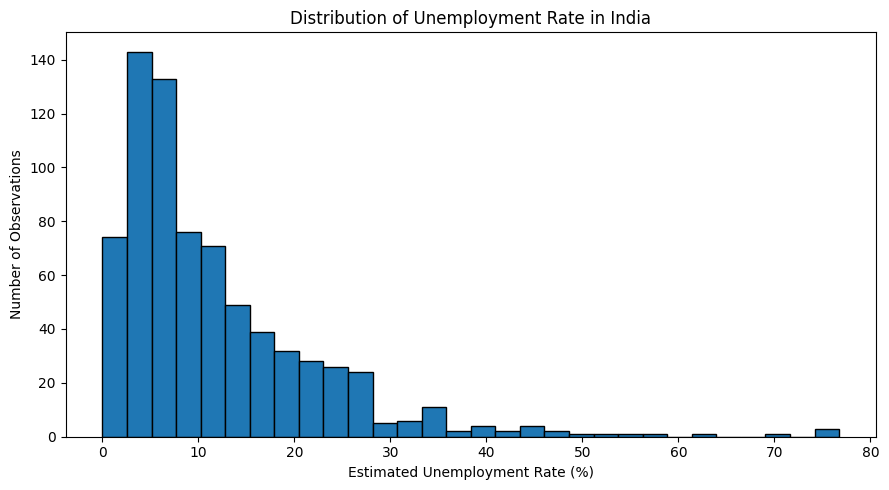

In [43]:
# Visualize the distribution of unemployment rates

plt.figure(figsize=(9, 5))

plt.hist(
    df["Estimated Unemployment Rate (%)"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Unemployment Rate in India")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

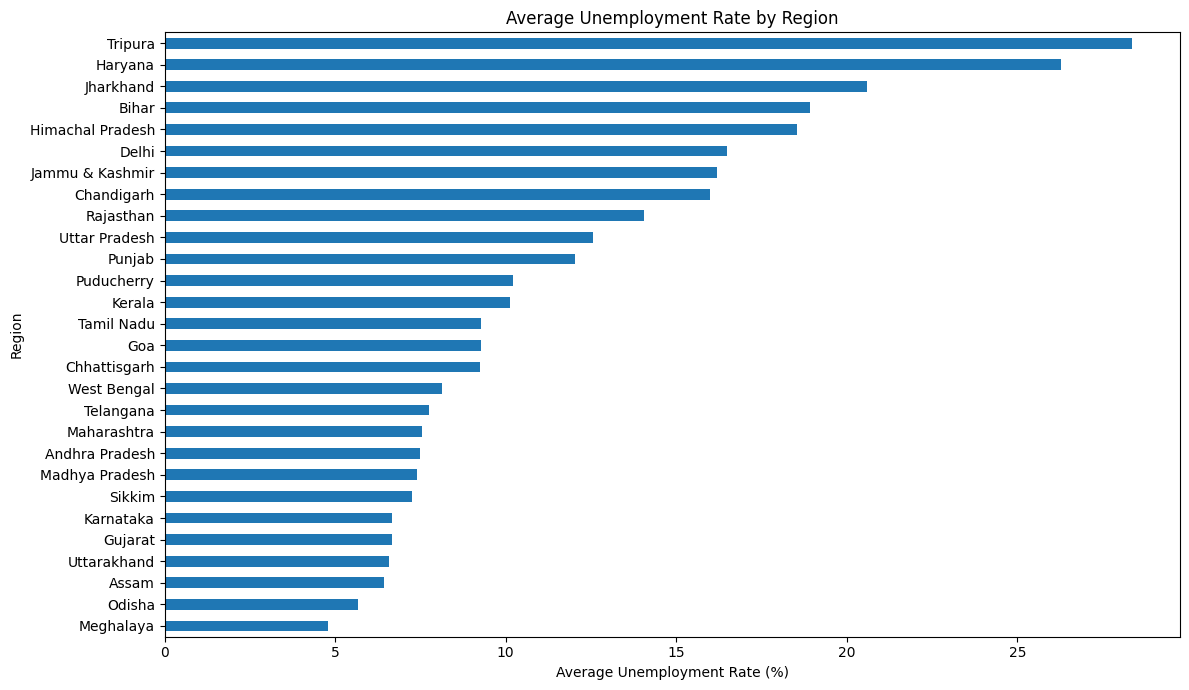

In [44]:
# Visualize average unemployment rate by region

plt.figure(figsize=(12, 7))

region_unemployment.sort_values().plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [45]:
# Extract year and month from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

print("Year range:", df["Year"].min(), "to", df["Year"].max())
print("\nAvailable years:")
print(sorted(df["Year"].unique()))

Year range: 2019 to 2020

Available years:
[np.int32(2019), np.int32(2020)]


In [46]:
# Calculate monthly average unemployment rate

monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_index()
)

print("Monthly unemployment trend:")
print(monthly_unemployment)

Monthly unemployment trend:
Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


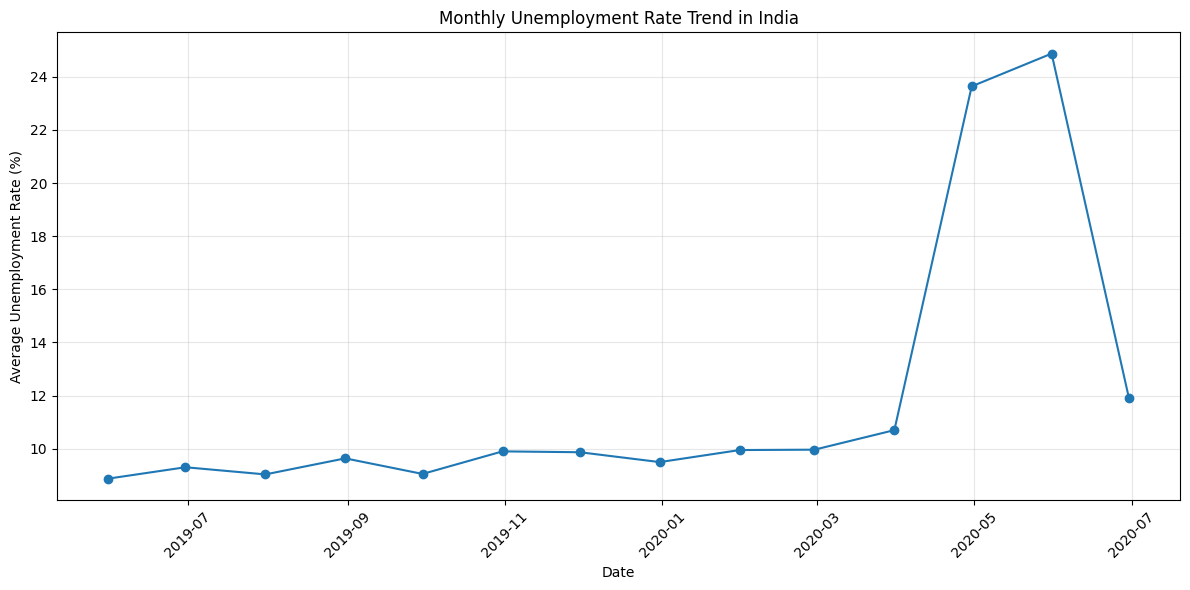

In [47]:
# Visualize monthly unemployment trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Compare average unemployment rate between 2019 and 2020

yearly_unemployment = (
    df.groupby("Year")["Estimated Unemployment Rate (%)"]
      .mean()
)

print("Average Unemployment Rate by Year:")
print(yearly_unemployment)

Average Unemployment Rate by Year:
Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


In [49]:
# Calculate percentage-point change from 2019 to 2020

if 2019 in yearly_unemployment.index and 2020 in yearly_unemployment.index:
    change = yearly_unemployment[2020] - yearly_unemployment[2019]

    print(f"\nChange from 2019 to 2020: {change:.2f} percentage points")


Change from 2019 to 2020: 5.70 percentage points


In [50]:
# Compare early 2020 and later 2020 unemployment rates

early_2020 = df[
    (df["Date"] >= "2020-01-01") &
    (df["Date"] < "2020-03-01")
]

covid_period = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]

early_2020_avg = early_2020["Estimated Unemployment Rate (%)"].mean()
covid_period_avg = covid_period["Estimated Unemployment Rate (%)"].mean()

print(f"Early 2020 average unemployment: {early_2020_avg:.2f}%")
print(f"March-June 2020 average unemployment: {covid_period_avg:.2f}%")
print(f"Difference: {covid_period_avg - early_2020_avg:.2f} percentage points")

Early 2020 average unemployment: 9.96%
March-June 2020 average unemployment: 17.77%
Difference: 7.82 percentage points


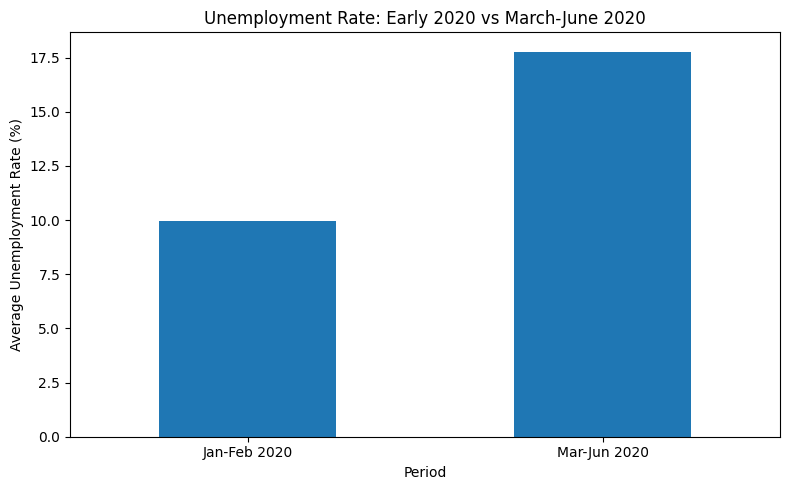

In [51]:
# Compare early 2020 and March-June 2020 unemployment

comparison = pd.Series({
    "Jan-Feb 2020": early_2020_avg,
    "Mar-Jun 2020": covid_period_avg
})

plt.figure(figsize=(8, 5))

comparison.plot(kind="bar")

plt.title("Unemployment Rate: Early 2020 vs March-June 2020")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [52]:
# Analyze monthly unemployment rates during 2020

monthly_2020 = (
    df[df["Year"] == 2020]
    .groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

print("Monthly Unemployment Rate - 2020:")
print(monthly_2020)

Monthly Unemployment Rate - 2020:
Month
1     9.950755
2     9.964717
3    10.700577
4    23.641569
5    24.875294
6    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


In [53]:
# Identify the month with the highest unemployment rate in 2020

peak_month = monthly_2020.idxmax()
peak_rate = monthly_2020.max()

print(f"Peak unemployment month in 2020: {peak_month}")
print(f"Peak average unemployment rate: {peak_rate:.2f}%")

Peak unemployment month in 2020: 5
Peak average unemployment rate: 24.88%


In [54]:
# Compare early 2020 with March-June 2020

early_2020_avg = df[
    (df["Date"] >= "2020-01-01") &
    (df["Date"] < "2020-03-01")
]["Estimated Unemployment Rate (%)"].mean()

covid_2020_avg = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]["Estimated Unemployment Rate (%)"].mean()

increase = covid_2020_avg - early_2020_avg
percentage_increase = (increase / early_2020_avg) * 100

print(f"Jan-Feb 2020 average: {early_2020_avg:.2f}%")
print(f"Mar-Jun 2020 average: {covid_2020_avg:.2f}%")
print(f"Increase: {increase:.2f} percentage points")
print(f"Relative increase: {percentage_increase:.2f}%")

Jan-Feb 2020 average: 9.96%
Mar-Jun 2020 average: 17.77%
Increase: 7.82 percentage points
Relative increase: 78.50%


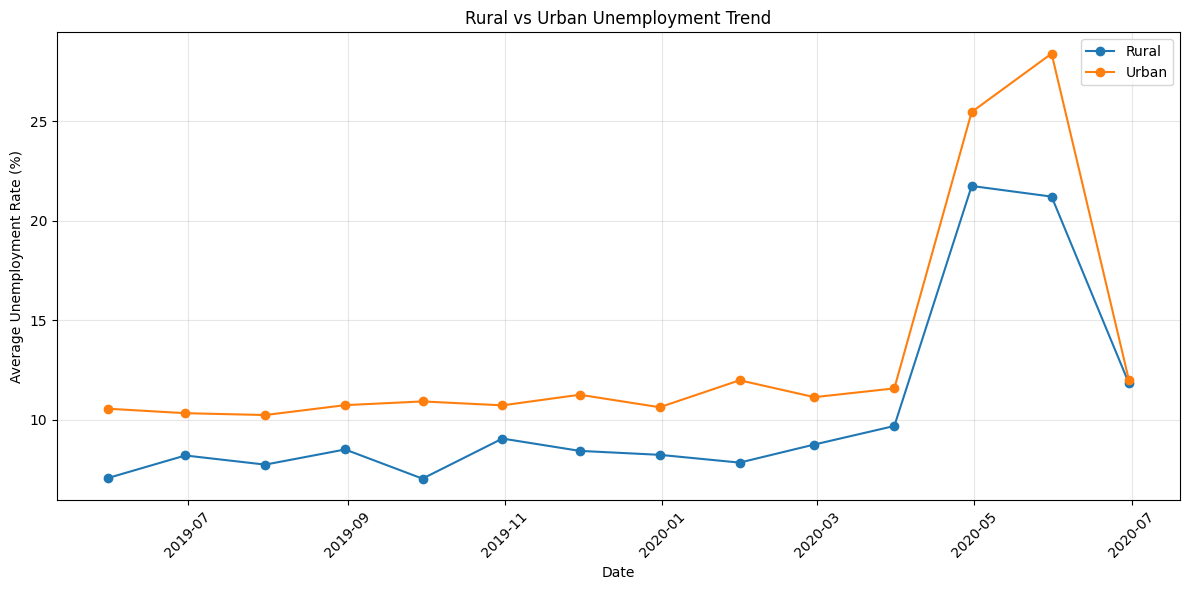

In [55]:
# Compare Rural and Urban unemployment trends over time

area_monthly = (
    df.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

for area in area_monthly["Area"].unique():
    subset = area_monthly[area_monthly["Area"] == area]

    plt.plot(
        subset["Date"],
        subset["Estimated Unemployment Rate (%)"],
        marker="o",
        label=area
    )

plt.title("Rural vs Urban Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# Analyze average unemployment by calendar month

monthly_pattern = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
)

print("Average unemployment by calendar month:")
print(monthly_pattern)

Average unemployment by calendar month:
Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


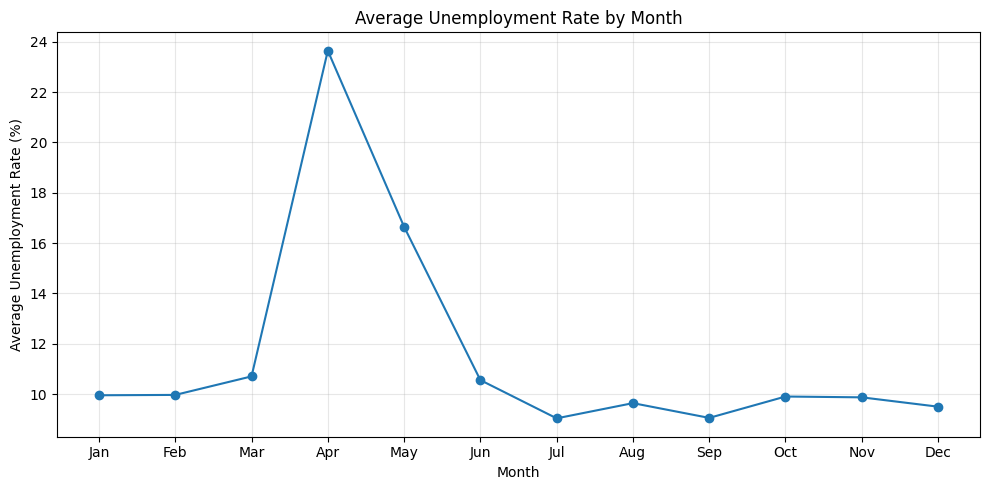

In [57]:
# Visualize average unemployment by calendar month

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

available_months = monthly_pattern.index

plt.figure(figsize=(10, 5))

plt.plot(
    available_months,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(available_months, [month_labels[m-1] for m in available_months])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Create a summary of key findings

summary = pd.DataFrame({
    "Metric": [
        "Overall Average Unemployment",
        "2019 Average (Available Period)",
        "2020 Average (Available Period)",
        "Highest Average Region",
        "Lowest Average Region",
        "Urban Average",
        "Rural Average"
    ],
    "Value": [
        f"{df['Estimated Unemployment Rate (%)'].mean():.2f}%",
        f"{yearly_unemployment.get(2019, np.nan):.2f}%",
        f"{yearly_unemployment.get(2020, np.nan):.2f}%",
        f"{highest_region} ({highest_rate:.2f}%)",
        f"{lowest_region} ({lowest_rate:.2f}%)",
        f"{area_unemployment.get('Urban', np.nan):.2f}%",
        f"{area_unemployment.get('Rural', np.nan):.2f}%"
    ]
})

summary

,Metric,Value
0,Overall Average Unemployment,11.79%
1,2019 Average (Available Period),9.40%
2,2020 Average (Available Period),15.10%
3,Highest Average Region,Tripura (28.35%)
4,Lowest Average Region,Meghalaya (4.80%)
5,Urban Average,13.17%
6,Rural Average,10.32%


In [60]:
# Final Key Findings

print("KEY FINDINGS - INDIAN UNEMPLOYMENT ANALYSIS")


print(f"\n1. Overall average unemployment rate: "
      f"{df['Estimated Unemployment Rate (%)'].mean():.2f}%")

print(f"\n2. 2019 average unemployment rate "
      f"(available observations): {yearly_unemployment[2019]:.2f}%")

print(f"3. 2020 average unemployment rate "
      f"(available observations): {yearly_unemployment[2020]:.2f}%")

print(f"\n4. Jan-Feb 2020 average: {early_2020_avg:.2f}%")
print(f"5. Mar-Jun 2020 average: {covid_2020_avg:.2f}%")
print(f"6. Increase during Mar-Jun period: "
      f"{increase:.2f} percentage points")
print(f"7. Relative increase: {percentage_increase:.2f}%")

print(f"\n8. Peak unemployment month in 2020: "
      f"{peak_month} ({peak_rate:.2f}%)")

print(f"\n9. Highest-average region: "
      f"{highest_region} ({highest_rate:.2f}%)")

print(f"10. Lowest-average region: "
      f"{lowest_region} ({lowest_rate:.2f}%)")

print(f"\n11. Urban average unemployment: "
      f"{area_unemployment['Urban']:.2f}%")

print(f"12. Rural average unemployment: "
      f"{area_unemployment['Rural']:.2f}%")

print("\n" + "=" * 60)

KEY FINDINGS - INDIAN UNEMPLOYMENT ANALYSIS

1. Overall average unemployment rate: 11.79%

2. 2019 average unemployment rate (available observations): 9.40%
3. 2020 average unemployment rate (available observations): 15.10%

4. Jan-Feb 2020 average: 9.96%
5. Mar-Jun 2020 average: 17.77%
6. Increase during Mar-Jun period: 7.82 percentage points
7. Relative increase: 78.50%

8. Peak unemployment month in 2020: 5 (24.88%)

9. Highest-average region: Tripura (28.35%)
10. Lowest-average region: Meghalaya (4.80%)

11. Urban average unemployment: 13.17%
12. Rural average unemployment: 10.32%



In [65]:
# ============================================
# CREATE VISUALIZATION DIRECTORY
# ============================================

import os

visualization_dir = "Visualizations"

os.makedirs(visualization_dir, exist_ok=True)

print(f"Visualization folder ready: {visualization_dir}/")

Visualization folder ready: Visualizations/


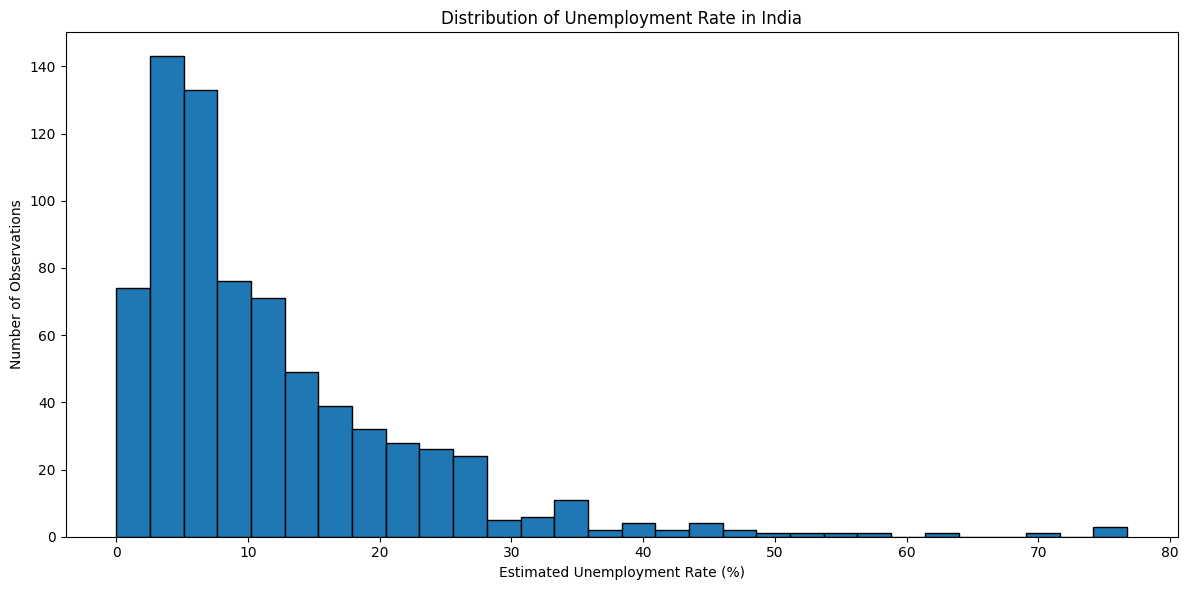

Saved: Visualizations/unemployment_distribution.png


In [66]:
# ============================================
# 1. UNEMPLOYMENT RATE DISTRIBUTION
# ============================================

plt.figure(figsize=(12, 6))

plt.hist(
    df["Estimated Unemployment Rate (%)"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Unemployment Rate in India")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.ylabel("Number of Observations")

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "unemployment_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/unemployment_distribution.png")

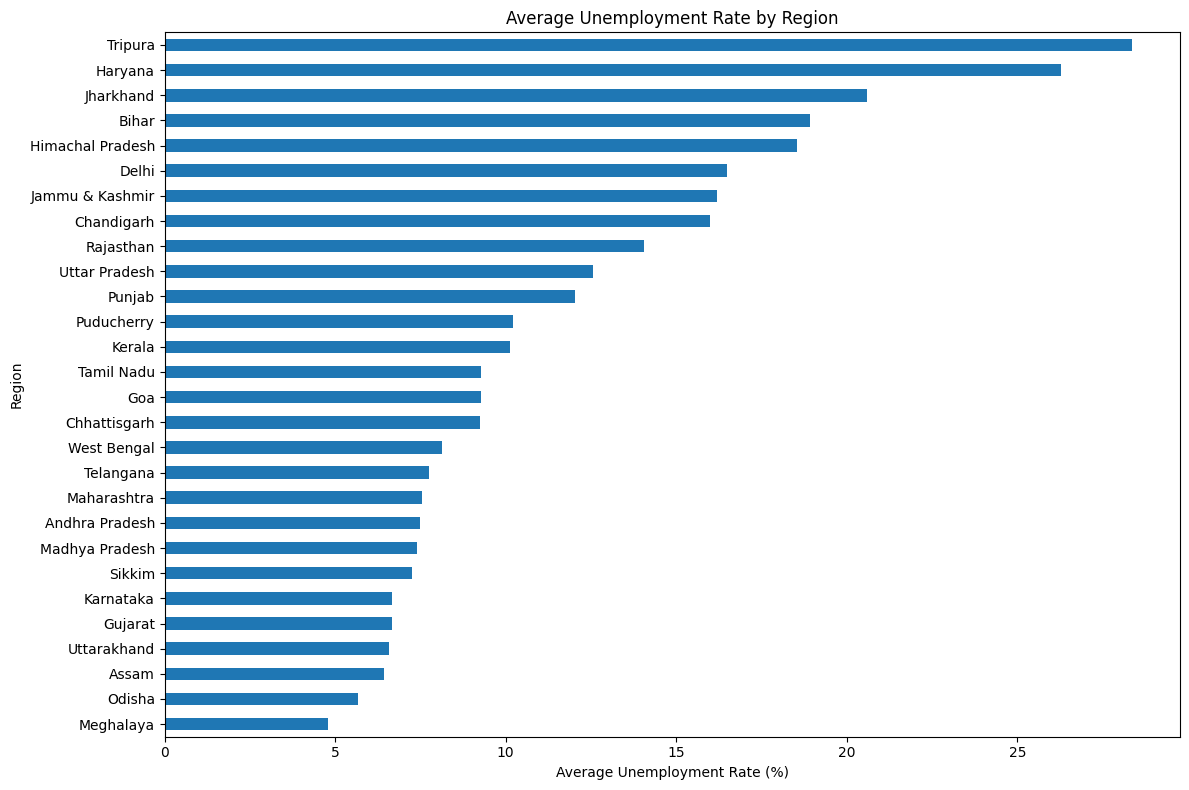

Saved: Visualizations/average_unemployment_by_region.png


In [67]:
# ============================================
# 2. AVERAGE UNEMPLOYMENT RATE BY REGION
# ============================================

region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

region_unemployment.plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "average_unemployment_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/average_unemployment_by_region.png")

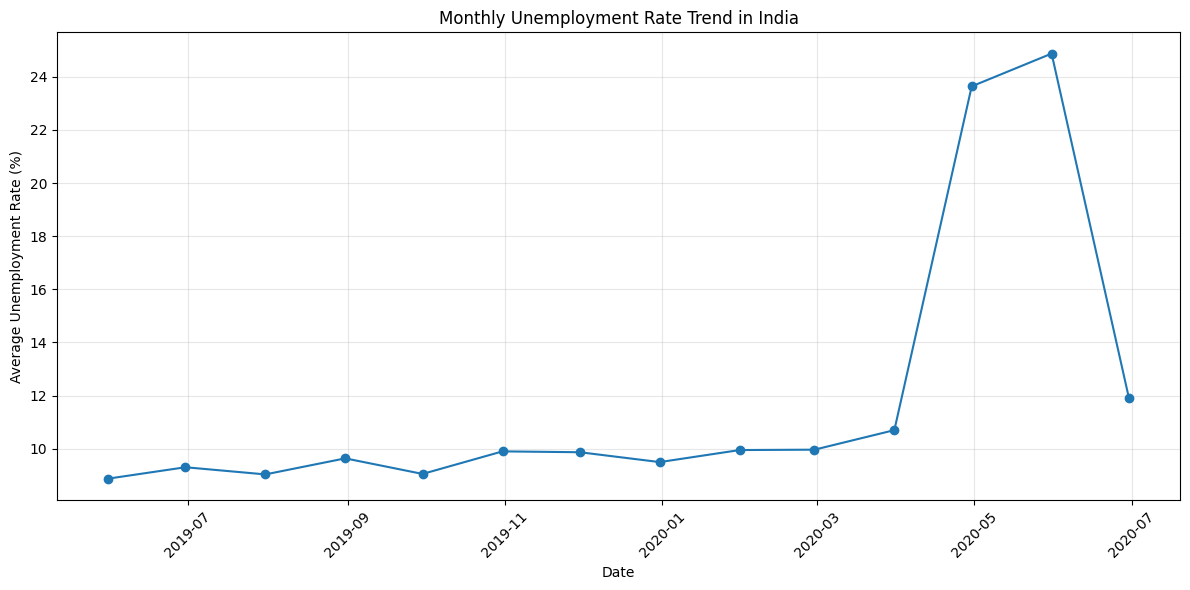

Saved: Visualizations/monthly_unemployment_trend.png


In [68]:
# ============================================
# 3. MONTHLY UNEMPLOYMENT TREND
# ============================================

# Calculate monthly average unemployment rate
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "monthly_unemployment_trend.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/monthly_unemployment_trend.png")

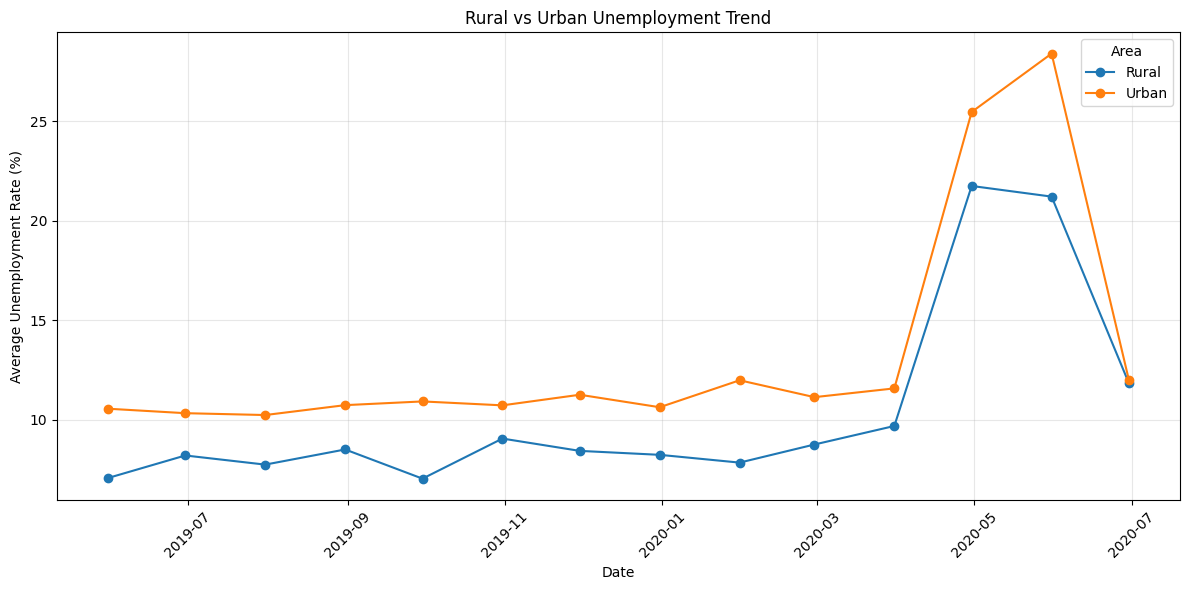

Saved: Visualizations/rural_vs_urban_trend.png


In [69]:
# ============================================
# 4. RURAL VS URBAN UNEMPLOYMENT TREND
# ============================================

# Calculate average unemployment by date and area
area_monthly = (
    df.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"]
    .mean()
    .unstack()
    .sort_index()
)

plt.figure(figsize=(12, 6))

for area in area_monthly.columns:
    plt.plot(
        area_monthly.index,
        area_monthly[area],
        marker="o",
        label=area
    )

plt.title("Rural vs Urban Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.legend(title="Area")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "rural_vs_urban_trend.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/rural_vs_urban_trend.png")

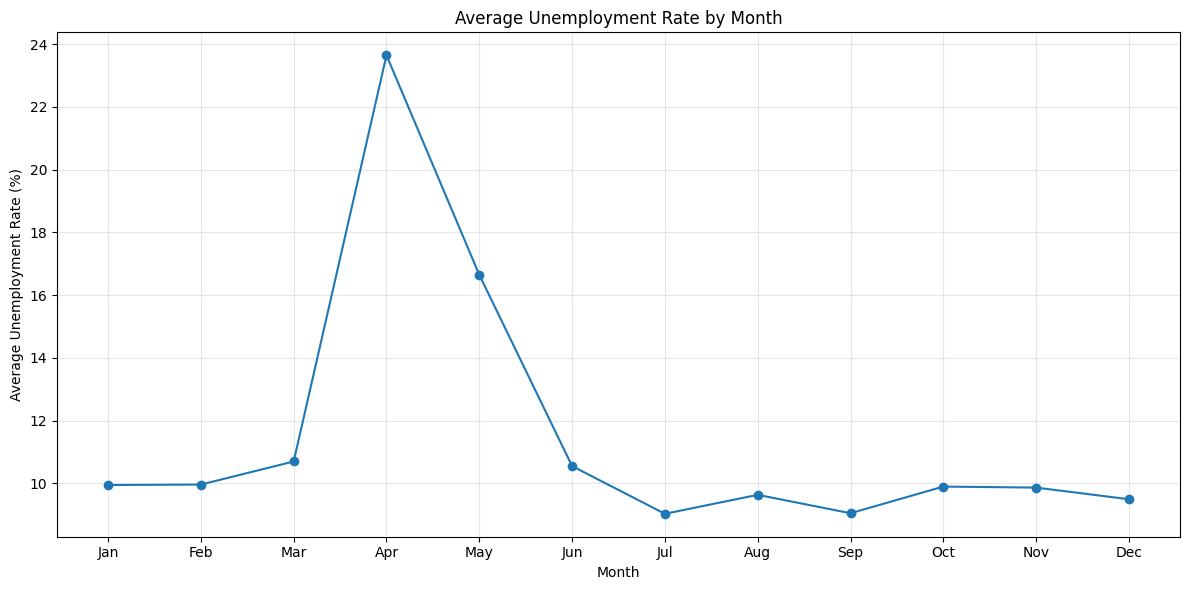

Saved: Visualizations/average_unemployment_by_month.png


In [70]:
# ============================================
# 5. AVERAGE UNEMPLOYMENT RATE BY MONTH
# ============================================

# Extract month from Date
df["Month"] = df["Date"].dt.month

monthly_average = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
)

# Month names for better visualization
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

monthly_average.index = monthly_average.index.map(month_names)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "average_unemployment_by_month.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Visualizations/average_unemployment_by_month.png")

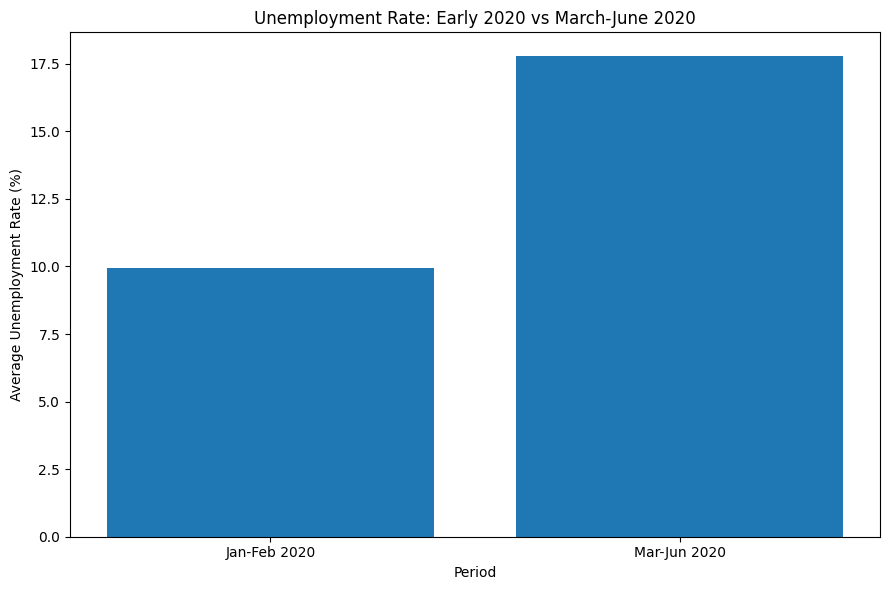

Jan-Feb 2020 Average: 9.96%
Mar-Jun 2020 Average: 17.77%
Saved: Visualizations/early_2020_vs_mar_jun_2020.png


In [71]:
# ============================================
# 6. EARLY 2020 VS MAR-JUNE 2020 COMPARISON
# ============================================

# Calculate period averages
early_2020_avg = df[
    (df["Date"] >= "2020-01-01") &
    (df["Date"] < "2020-03-01")
]["Estimated Unemployment Rate (%)"].mean()

mar_jun_2020_avg = df[
    (df["Date"] >= "2020-03-01") &
    (df["Date"] <= "2020-06-30")
]["Estimated Unemployment Rate (%)"].mean()

periods = ["Jan-Feb 2020", "Mar-Jun 2020"]
values = [early_2020_avg, mar_jun_2020_avg]

plt.figure(figsize=(9, 6))

plt.bar(periods, values)

plt.title("Unemployment Rate: Early 2020 vs March-June 2020")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()

# Save visualization
plt.savefig(
    os.path.join(
        visualization_dir,
        "early_2020_vs_mar_jun_2020.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Jan-Feb 2020 Average:", f"{early_2020_avg:.2f}%")
print("Mar-Jun 2020 Average:", f"{mar_jun_2020_avg:.2f}%")
print("Saved: Visualizations/early_2020_vs_mar_jun_2020.png")

# Key Findings

The analysis of the Indian unemployment dataset produced the following key findings:

1. The overall average unemployment rate was **11.79%**.

2. The average unemployment rate for the available **2019 observations was 9.40%**.

3. The average unemployment rate for the available **2020 observations was 15.10%**.

4. The average unemployment rate during **January–February 2020 was 9.96%**.

5. The average unemployment rate during **March–June 2020 increased to 17.77%**.

6. This represents an increase of **7.82 percentage points**, equivalent to a **78.50% relative increase**.

7. **May 2020** recorded the highest monthly average unemployment rate in the analyzed 2020 period at approximately **24.88%**.

8. **Tripura** recorded the highest average regional unemployment rate at **28.35%**.

9. **Meghalaya** recorded the lowest average regional unemployment rate at **4.80%**.

10. The average unemployment rate in **Urban areas was 13.17%**, compared with **10.32% in Rural areas**.

---

#  Conclusion

The analysis shows a substantial increase in unemployment during the March–June 2020 period compared with January–February 2020. The monthly trend indicates a sharp rise during April and May 2020, followed by a decline in June.

Regional analysis also shows considerable variation in average unemployment rates across regions. Urban areas recorded a higher average unemployment rate than rural areas in the analyzed dataset.

Overall, the analysis demonstrates how data cleaning, statistical analysis, regional comparisons, and visualization can be used to identify important patterns in unemployment data.

> **Note:** These findings are based on the available observations in the provided dataset and should be interpreted within the dataset's coverage and limitations.